In [1]:
import os
import sys
from loguru import logger
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from hippy2d.datasets import ColorectalHistology
from hippy2d.trainer import get_trainer

# Load the broken model
import yaml
config_path = "/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/configs/runs/learnable/learnable-s1.yaml" 

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

config['d_hparams']['data_dir'] = "/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/data" 

/home/karella/.conda/envs/hippy2d/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Samples

from hippy2d.factory import get_datamodule

config['d_hparams']['batch_size'] = 64
#config['d_hparams']['use_circ_mask'] = False

ds = get_datamodule(config['dataset_name'], config['d_hparams'])
ds.prepare_data()
ds.setup(None)

# Model Artifacts
#model_path = "/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/hippy2d/xxfl14nc/checkpoints/epoch=0-step=15.ckpt"

#best_checkpoint = torch.load(model_path, weights_only=False)
#_result = model.load_state_dict(best_checkpoint['state_dict'], strict=False )
#print(f"Best model loading from {model_path} : {_result}")
# Data
train_dl = ds.train_dataloader()

In [5]:
import escnn
from hippy2d.blocks import InvGatedBlock, GatedBlock

in_channels = 3
_block = InvGatedBlock
r2_act = escnn.gspaces.rot2dOnR2(N=-1, maximum_frequency=3)

class DummyModel(torch.nn.Module):
    def __init__(self, r2_act, in_channels=3, depth=64):
        super(DummyModel, self).__init__()
        self.channels = [16 for _ in range(depth)]
        kernel_size = 5
        self.depth = depth + 1

        self.in_type = escnn.nn.FieldType(r2_act,
                                    in_channels * [r2_act.trivial_repr])
        self.stem = _block(r2_act=r2_act,
                    in_type=self.in_type,
                    padding=0,
                    out_channels=16,
                    kernel_size=7)
        _layers = []
        out_type = self.stem.out_type
        # Feature Extractor 
        for layer_idx in range(len(self.channels)):
            layer = _block(r2_act=r2_act,
                        in_type=out_type,
                        padding=2,
                        out_channels=self.channels[layer_idx],
                        kernel_size=kernel_size)
            _layers.append(layer)
            out_type = layer.out_type
        self.feature_extractor = escnn.nn.SequentialModule(*_layers)

    def forward(self, x, nth=-1):
        x = escnn.nn.GeometricTensor(x, self.in_type)
        x = self.stem(x)
        if nth == 0:
            return x, self.channels[0]
        else: 
            x = self.feature_extractor[:nth](x)
        return x, self.channels[nth - 1]

In [6]:
# Plot train/val/test samples
def plot_samples(dataloader, title, num_samples=5):
    data_iter = next(iter(dataloader))
    if len(data_iter) == 2:
        images, labels = data_iter
    else:
        batch, batch_idx, dl_idx = data_iter
        images, labels = batch
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        img = images[i].numpy().transpose((1, 2, 0))
        plt.imshow(img)
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

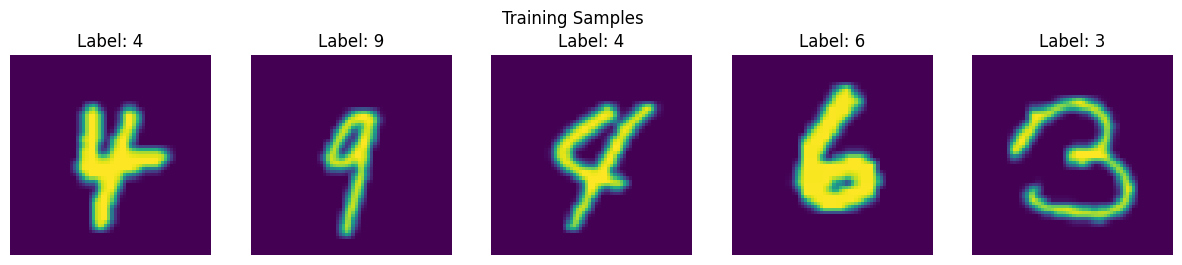

In [7]:
plot_samples(train_dl, "Training Samples")

In [8]:
model = DummyModel(r2_act, in_channels=1)
model.eval()
model.stem.norm.training

False

In [9]:
from einops import rearrange
from collections import defaultdict
it  = iter(train_dl)
_ = next(it)  # skip first batch to avoid any caching issues
data_iter = next(it)
images, labels = data_iter
maximum_frequency = len(r2_act.irreps)-1
normalize = True
dict_mean = defaultdict(list)
dict_std = defaultdict(list)

if normalize: 
    images -= images.mean(dim=(0,2,3))[:, None, None]
    images /= torch.clamp(images.std(dim=(0,2,3)), min=1e-6)[:, None, None]
# Batch stats
print("Batch-wise Feature Statistics:")
print(f"Input: {images.mean():.2f} ± {images.std():.2f} min {images.min():.2f} max {images.max():.2f}")

for n_layer in range(0, model.depth):
    print(f"Layer {n_layer}:")
    # get sample batch 
    x, ch= model.forward(images[:1], nth=n_layer)  
    trivials = x.tensor[:, :ch].detach()
    dict_mean[0].append(trivials.mean().item())
    dict_std[0].append(trivials.std().item()) 
    print(f"\tType 0: {trivials.mean():.2f} ± {trivials.std():2f}")
    print(f"\tType 0: {trivials.mean():.2f} ± {trivials.std():2f}")
    non_trivials = x.tensor[:, ch:].detach()
    non_trivials = rearrange(non_trivials, 'b (o ch co) h w -> b o ch co h w', o=maximum_frequency, co=2, ch=ch) 
    # Non-Trivials: Batch x Orders x Channels x Complex x H x W
    for o in range(1, maximum_frequency):
        order_components = non_trivials[:, o, :, :, :, :]
        magnitudes = torch.linalg.vector_norm(order_components, dim=2)  
        dict_mean[o+1].append(magnitudes.mean().item())
        dict_std[o+1].append(magnitudes.std().item())
        print(f"\tType {o+1}: {magnitudes.mean():.2f} ± {magnitudes.std():2f}")

Batch-wise Feature Statistics:
Input: -0.00 ± 1.00 min -0.40 max 3.39
Layer 0:
	Type 0: 0.54 ± 1.692904
	Type 0: 0.54 ± 1.692904
	Type 2: 0.33 ± 0.713319
	Type 3: 0.10 ± 0.256554
Layer 1:
	Type 0: 0.24 ± 2.039435
	Type 0: 0.24 ± 2.039435
	Type 2: 0.29 ± 0.477312
	Type 3: 0.00 ± 0.000000
Layer 2:
	Type 0: 0.57 ± 2.555256
	Type 0: 0.57 ± 2.555256
	Type 2: 0.25 ± 0.385561
	Type 3: 0.00 ± 0.000000
Layer 3:
	Type 0: 0.22 ± 1.112586
	Type 0: 0.22 ± 1.112586
	Type 2: 0.25 ± 0.350606
	Type 3: 0.00 ± 0.000000
Layer 4:
	Type 0: 0.05 ± 1.095769
	Type 0: 0.05 ± 1.095769
	Type 2: 0.20 ± 0.260304
	Type 3: 0.00 ± 0.000000
Layer 5:
	Type 0: 0.44 ± 1.389894
	Type 0: 0.44 ± 1.389894
	Type 2: 0.18 ± 0.239957
	Type 3: 0.00 ± 0.000000
Layer 6:
	Type 0: 0.74 ± 1.720417
	Type 0: 0.74 ± 1.720417
	Type 2: 0.16 ± 0.206211
	Type 3: 0.00 ± 0.000000
Layer 7:
	Type 0: 0.33 ± 1.571249
	Type 0: 0.33 ± 1.571249
	Type 2: 0.16 ± 0.210066
	Type 3: 0.00 ± 0.000000
Layer 8:
	Type 0: 0.70 ± 1.977406
	Type 0: 0.70 ± 1.977406

ValueError: x and y must have same first dimension, but have shapes (65,) and (0,)

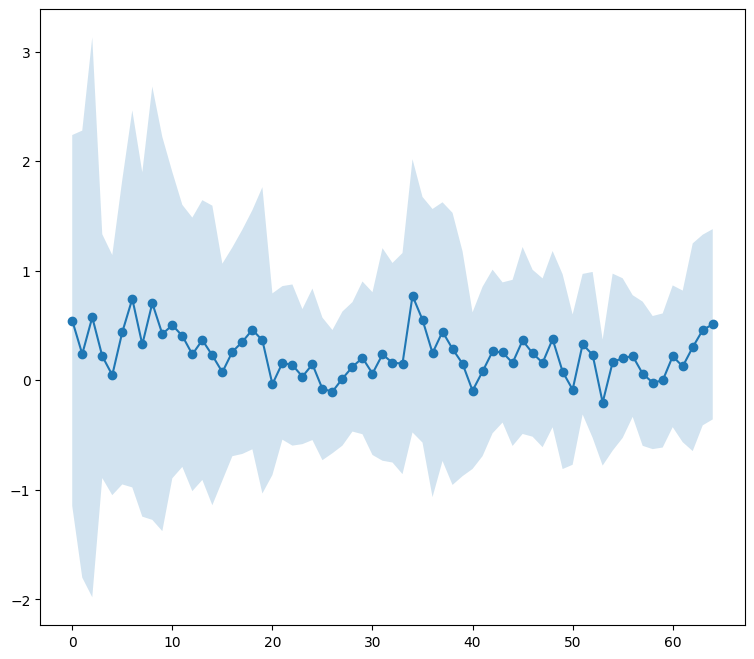

In [10]:
import matplotlib.pyplot as plt

# Plot mean and std for each type across layers
layers = list(range(model.depth))
plt.figure(figsize=(20, 8))

# Linear scale plot (mean ± std)
ax1 = plt.subplot(1, 2, 1)
for o in range(maximum_frequency + 1):
    means = np.array(dict_mean[o])
    stds = np.array(dict_std[o])
    ax1.plot(layers, means, label=f'Type {o}', marker='o')
    ax1.fill_between(layers, means - stds, means + stds, alpha=0.2)
ax1.set_title("Activation Statistics per Layer (Linear)")
ax1.set_xlabel('Number of Layer')
ax1.set_ylabel('Magnitude Mean ± STD')
ax1.grid(True, which='both', axis='y', linestyle='--')
ax1.legend(loc='upper left')

# Log scale plot (mean ± std)
ax2 = plt.subplot(1, 2, 2)
for o in range(maximum_frequency + 1):
    means = np.array(dict_mean[o])
    ax2.plot(layers, means, label=f'Type {o}', marker='o')
ax2.set_yscale('log')
ax2.set_title("Activation Statistics per Layer (Log)")
ax2.set_xlabel('Number of Layer')
ax2.set_ylabel('Log Magnitude Mean')
ax2.grid(True, which='both', axis='y', linestyle='--')
ax2.legend(loc='upper left')

# Title for both subplots
plt.suptitle("Our Block")
plt.tight_layout()
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PreActBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)

        # Optional projection when shape changes
        self.shortcut = None
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                      stride=stride, bias=False)

        self._init_weights()

    def _init_weights(self):
        # He init for convs
        for m in [self.conv1, self.conv2] + ([self.shortcut] if self.shortcut else []):
            if m is not None:
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        
        # BN: default gamma=1, beta=0 is fine, but:
        #  Optional: zero-init last BN gamma to make block start as identity
        nn.init.ones_(self.bn1.weight)
        nn.init.zeros_(self.bn1.bias)

        nn.init.zeros_(self.bn2.weight)   # <- important trick
        nn.init.zeros_(self.bn2.bias)

    def forward(self, x):
        out = self.bn1(x)
        out = F.relu(out)
        shortcut = self.shortcut(out) if self.shortcut is not None else x

        out = self.conv1(out)
        out = self.bn2(out)
        out = F.relu(out)
        out = self.conv2(out)

        out += shortcut
        return out



In [ ]:
images.shape

In [ ]:
from torch import nn 
# Build a simple stack of pre-activation ResNet blocks
depth = 64
channels = 16

# First conv to go to 'channels'
stem = nn.Conv2d(1, channels, kernel_size=3, stride=1, padding=1, bias=False)
nn.init.kaiming_normal_(stem.weight, mode='fan_out', nonlinearity='relu')

blocks = nn.ModuleList([
    PreActBlock(channels, channels, stride=1) for _ in range(depth)
])

model = nn.Sequential(stem, *blocks)
model.eval()   # important: BatchNorm in eval mode for this test

means = []
stds = []

with torch.no_grad():
    h = images
    for i, layer in enumerate(model):
        h = layer(h)
        means.append(h.mean().item())
        stds.append(h.std().item())

print("Means per layer:", means)
print("Stds per layer:", stds)
means = np.array(means)
stds = np.array(stds)


In [ ]:
import matplotlib.pyplot as plt

# Plot mean and std for each type across layers
layers = list(range(depth+1))
plt.figure(figsize=(20, 8))

# Linear scale plot (mean ± std)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(layers, means, label=f'Type 0', marker='o')
ax1.fill_between(layers, means - stds, means + stds, alpha=0.2)
ax1.set_title("Activation Statistics per Layer (Linear)")
ax1.set_xlabel('Number of Layer')
ax1.set_ylabel('Magnitude Mean ± STD')
ax1.grid(True, which='both', axis='y', linestyle='--')
ax1.legend(loc='upper left')

# Log scale plot (mean ± std)
ax2 = plt.subplot(1, 2, 2)
ax2.plot(layers, means, label=f'Type 0', marker='o')
ax2.set_yscale('log')
ax2.set_title("Activation Statistics per Layer (Log)")
ax2.set_xlabel('Number of Layer')
ax2.set_ylabel('Log Magnitude Mean')
ax2.grid(True, which='both', axis='y', linestyle='--')
ax2.legend(loc='upper left')

# Title for both subplots
plt.suptitle("What ChatGPT says its Resnet Block")
plt.tight_layout()